# Policy Gradients and Actor-Critic

In the previous notebook, we learned a value function:

$$
Q_\phi(x,u)
$$

and obtained a policy through:

$$
\pi(x)=
\arg\max_u Q_\phi(x,u).
$$

This works naturally when the action space is discrete.

However, many robotics and control problems have continuous actions:

$$
u\in\mathbb R^m.
$$

For example, a vehicle may use:

$$
u=
[a,\delta],
$$

where acceleration and steering angle are continuous.

Instead of learning a value function and then optimizing over actions,
policy-gradient methods directly parameterize the policy:

$$
\boxed{
\pi_\theta(u|x)
}
$$

and optimize its parameters to maximize expected return.

This notebook develops the progression:

$$
\boxed{
\text{Policy Gradient}
\rightarrow
\text{REINFORCE}
\rightarrow
\text{Baseline}
\rightarrow
\text{Advantage}
\rightarrow
\text{Actor-Critic}
}
$$

## Setup

We use a simple one-dimensional vehicle model.

The state is:

$$
x_t=
\begin{bmatrix}
p_t\\
v_t
\end{bmatrix},
$$

where:

- $p_t$ is the vehicle position,
- $v_t$ is the vehicle velocity.

The control input is longitudinal acceleration.

For the first policy-gradient example, we discretize the control space:

$$
u_t\in\{-1,0,+1\}.
$$

The vehicle dynamics are:

$$
p_{t+1}=
p_t+\Delta t\,v_t,
$$

$$
v_{t+1}=
v_t+\Delta t\,u_t.
$$

The goal is to learn a policy that drives the vehicle toward a desired
velocity:

$$
v_{\text{ref}}.
$$

This environment is deliberately simple so that we can focus on the policy
gradient algorithm rather than environment complexity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
DT = 0.1
V_REF = 5.0

ACTIONS = np.array([
    -1.0,   # decelerate
     0.0,   # coast
     1.0    # accelerate
])

N_ACTIONS = len(ACTIONS)

In [3]:
def environment_step(state, action_index):

    position, velocity = state

    acceleration = ACTIONS[action_index]

    next_position = (
        position
        + DT * velocity
    )

    next_velocity = (
        velocity
        + DT * acceleration
    )

    next_state = np.array([
        next_position,
        next_velocity
    ])

    velocity_error = (
        next_velocity - V_REF
    )

    reward = -velocity_error**2

    return next_state, reward

## 1. Policy Network for the 1D Car

The vehicle state is:

$$
x_t=
\begin{bmatrix}
p_t\\
v_t
\end{bmatrix}.
$$

The policy receives this state and outputs a probability distribution over the
three discrete acceleration commands:

$$
u_t\in\{-1,0,+1\}.
$$

The policy is therefore:

$$
\pi_\theta(u|x).
$$

For a given state, the network outputs:

$$
\pi_\theta(\cdot|x)=
[
P(u=-1|x),
P(u=0|x),
P(u=+1|x)
].
$$

The probabilities are produced using a softmax layer so that:

$$
\sum_u \pi_\theta(u|x)=1.
$$

In [4]:
class PolicyNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, N_ACTIONS)
        )

    def forward(self, state):

        logits = self.network(state)

        probabilities = torch.softmax(
            logits,
            dim=-1
        )

        return probabilities

In [5]:
policy = PolicyNetwork()

## 2. State Representation

The policy network receives both position and velocity.

To improve numerical conditioning, we scale the state before passing it to the
network.

We use:

$$
\tilde p=
\frac{p}{P_{\text{scale}}},
$$

and:

$$
\tilde v=
\frac{v}{V_{\text{scale}}}.
$$

The normalized state is:

$$
\tilde x=
\begin{bmatrix}
\tilde p\\
\tilde v
\end{bmatrix}.
$$

In [6]:
P_SCALE = 50.0
V_SCALE = 10.0


def state_to_tensor(state):

    position, velocity = state

    normalized_state = np.array([
        position / P_SCALE,
        velocity / V_SCALE
    ])

    return torch.tensor(
        normalized_state,
        dtype=torch.float32
    ).unsqueeze(0)

## 3. Sampling an Action From the Policy

During training, the policy is stochastic.

Given a state:

$$
x_t,
$$

the network produces probabilities:

$$
\pi_\theta(\cdot|x_t).
$$

An action is sampled from this distribution:

$$
\boxed{
u_t
\sim
\pi_\theta(\cdot|x_t).
}
$$

The sampled action determines the acceleration applied to the vehicle.

We also store:

$$
\log\pi_\theta(u_t|x_t),
$$

because this quantity will be used in the policy-gradient update.

In [7]:
def sample_action(policy, state):

    state_tensor = state_to_tensor(
        state
    )

    probabilities = policy(
        state_tensor
    )[0]

    distribution = torch.distributions.Categorical(
        probabilities
    )

    action_index = distribution.sample()

    log_probability = distribution.log_prob(
        action_index
    )

    return (
        action_index.item(),
        log_probability
    )

## 4. Generating a Trajectory

A policy rollout generates a trajectory:

$$
\tau=
(x_0,u_0,r_1,x_1,u_1,r_2,\ldots,x_T).
$$

At every time step:

1. Observe the current state.
2. Sample an action from the policy.
3. Apply the corresponding acceleration.
4. Observe the next state and reward.
5. Store the action log-probability and reward.

For the 1D vehicle, the trajectory is generated using a fixed horizon:

$$
T.
$$

In [8]:
EPISODE_LENGTH = 100


def generate_episode(policy):

    state = np.array([
        0.0,   # initial position
        0.0    # initial velocity
    ])

    states = []
    actions = []
    rewards = []
    log_probs = []

    for _ in range(EPISODE_LENGTH):

        action_index, log_prob = sample_action(
            policy,
            state
        )

        next_state, reward = environment_step(
            state,
            action_index
        )

        states.append(state.copy())
        actions.append(action_index)
        rewards.append(reward)
        log_probs.append(log_prob)

        state = next_state

    return (
        states,
        actions,
        rewards,
        log_probs
    )

## 5. Probability of a Trajectory

A complete trajectory is generated by alternating between the policy and the
environment dynamics.

Its probability is:

$$
p_\theta(\tau)=
p(x_0)
\prod_{t=0}^{T-1}
\pi_\theta(u_t|x_t)
p(x_{t+1}|x_t,u_t).
$$

The terms have different meanings:

$$
p(x_0)
$$

describes the initial-state distribution,

$$
\pi_\theta(u_t|x_t)
$$

describes the probability of selecting an action,

and:

$$
p(x_{t+1}|x_t,u_t)
$$

describes the environment dynamics.

Only the policy depends on the learnable parameters:

$$
\theta.
$$

## 6. Why the Environment Dynamics Disappear?

Taking the logarithm of the trajectory probability gives:

$$
\log p_\theta(\tau)=
\log p(x_0)
+
\sum_{t=0}^{T-1}
\log\pi_\theta(u_t|x_t)
+
\sum_{t=0}^{T-1}
\log p(x_{t+1}|x_t,u_t).
$$

Differentiating with respect to the policy parameters:

$$
\nabla_\theta
\log p_\theta(\tau).
$$

The initial-state distribution does not depend on $\theta$:

$$
\nabla_\theta\log p(x_0)=0.
$$

The environment dynamics also do not depend on $\theta$:

$$
\nabla_\theta
\log p(x_{t+1}|x_t,u_t)=
0.
$$

Therefore:

$$
\boxed{
\nabla_\theta
\log p_\theta(\tau)=
\sum_{t=0}^{T-1}
\nabla_\theta
\log\pi_\theta(u_t|x_t)
}
$$

This means that policy gradients do not require gradients through the
environment dynamics.

## 7. The REINFORCE Gradient

The policy-gradient objective is:

$$
J(\theta)=
\mathbb E_{\tau\sim\pi_\theta}
[
R(\tau)
].
$$

Using the log-derivative trick:

$$
\nabla_\theta J=
\mathbb E
\left[
R(\tau)
\nabla_\theta
\log p_\theta(\tau)
\right].
$$

Since:

$$
\nabla_\theta
\log p_\theta(\tau)=
\sum_t
\nabla_\theta
\log\pi_\theta(u_t|x_t),
$$

we obtain:

$$
\boxed{
\nabla_\theta J=
\mathbb E
\left[
R(\tau)
\sum_t
\nabla_\theta
\log\pi_\theta(u_t|x_t)
\right].
}
$$

Using a sampled trajectory gives the Monte Carlo estimate:

$$
\boxed{
\nabla_\theta J
\approx
R(\tau)
\sum_t
\nabla_\theta
\log\pi_\theta(u_t|x_t).
}
$$

This is the basic idea behind REINFORCE.

## 8. Intuition Behind the Policy Gradient

The term:

$$
\nabla_\theta
\log\pi_\theta(u_t|x_t)
$$

describes how the policy parameters should change to increase the probability
of the sampled action.

The return determines whether that sampled action should become more or less
likely.

If:

$$
R(\tau)>0,
$$

gradient ascent increases the probability of actions that contributed to the
trajectory.

If:

$$
R(\tau)<0,
$$

those actions become less likely.

The policy therefore learns through the principle:

$$
\boxed{
\text{actions associated with better outcomes become more probable}
}
$$

## 9. Reward-to-Go

Using the total trajectory return for every action includes rewards that
occurred before that action was selected.

However, an action at time $t$ cannot influence past rewards.

Therefore, we use the return from time $t$ onward:

$$
G_t=
\sum_{k=t}^{T-1}
\gamma^{k-t}r_{k+1}.
$$

The policy-gradient estimator becomes:

$$
\boxed{
\nabla_\theta J
\approx
\sum_{t=0}^{T-1}
G_t
\nabla_\theta
\log\pi_\theta(u_t|x_t).
}
$$

This gives each action credit only for rewards that occur after that action.

## 10. Computing Reward-to-Go

For a trajectory containing rewards:

$$
r_1,r_2,\ldots,r_T,
$$

we compute:

$$
G_t=
r_{t+1}
+
\gamma r_{t+2}
+
\gamma^2r_{t+3}
+\cdots.
$$

These returns can be calculated efficiently by iterating backward through the
recorded rewards.

In [9]:
def compute_returns(
    rewards,
    gamma=0.99
):

    returns = []

    G = 0.0

    for reward in reversed(rewards):

        G = reward + gamma * G

        returns.append(G)

    returns.reverse()

    return torch.tensor(
        returns,
        dtype=torch.float32
    )

## 11. REINFORCE Loss

The REINFORCE gradient is:

$$
\nabla_\theta J
\approx
\sum_t
G_t
\nabla_\theta
\log\pi_\theta(u_t|x_t).
$$

We want to maximize:

$$
J(\theta).
$$

However, standard optimizers perform gradient descent.

Therefore, we define the loss:

$$
\boxed{
L(\theta)=-
\sum_t
G_t
\log\pi_\theta(u_t|x_t).
}
$$

Minimizing this loss performs gradient ascent on the expected return.

In [10]:
def reinforce_update(
    policy,
    optimizer,
    rewards,
    log_probs,
    gamma=0.99
):

    returns = compute_returns(
        rewards,
        gamma
    )

    log_probs = torch.stack(
        log_probs
    )

    loss = -torch.sum(
        returns * log_probs
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    return loss.item()

## 13. Training the 1D Car With REINFORCE

The complete REINFORCE loop is:

1. Generate one trajectory using the current policy.
2. Compute the reward-to-go:

$$
G_t.
$$

3. Compute the policy loss:

$$
L(\theta)=-
\sum_t
G_t
\log\pi_\theta(u_t|x_t).
$$

4. Backpropagate through the policy network.
5. Update the policy parameters.
6. Generate a new trajectory using the updated policy.

This process repeats over many episodes.

In [29]:
policy = PolicyNetwork()

optimizer = optim.Adam(
    policy.parameters(),
    lr=1e-3
)

N_EPISODES = 10_000
GAMMA = 0.99

episode_returns = []
loss_history = []

In [30]:
for episode in range(N_EPISODES):

    (
        states,
        actions,
        rewards,
        log_probs
    ) = generate_episode(policy)

    loss = reinforce_update(
        policy,
        optimizer,
        rewards,
        log_probs,
        gamma=GAMMA
    )

    episode_return = np.sum(rewards)

    episode_returns.append(
        episode_return
    )

    loss_history.append(
        loss
    )

    if episode % 100 == 0:

        print(
            f"Episode {episode:4d} | "
            f"Return: {episode_return:8.2f} | "
            f"Loss: {loss:8.2f}"
        )

Episode    0 | Return: -1991.38 | Loss: -75112.82
Episode  100 | Return:  -567.87 | Loss: -6137.87
Episode  200 | Return:  -725.93 | Loss: -12533.30
Episode  300 | Return:  -639.14 | Loss: -8028.02
Episode  400 | Return:  -587.62 | Loss: -6782.86
Episode  500 | Return:  -512.97 | Loss: -4594.48
Episode  600 | Return:  -579.36 | Loss: -5798.19
Episode  700 | Return:  -478.10 | Loss: -2615.84
Episode  800 | Return:  -486.52 | Loss: -2838.34
Episode  900 | Return:  -424.46 | Loss:  -796.81
Episode 1000 | Return:  -425.76 | Loss:  -802.15
Episode 1100 | Return:  -436.65 | Loss:  -924.93
Episode 1200 | Return:  -435.15 | Loss: -1066.61
Episode 1300 | Return:  -420.89 | Loss:  -546.35
Episode 1400 | Return:  -410.24 | Loss:  -340.69
Episode 1500 | Return:  -426.16 | Loss:  -746.82
Episode 1600 | Return:  -420.68 | Loss:  -490.05
Episode 1700 | Return:  -415.57 | Loss:  -440.20
Episode 1800 | Return:  -434.34 | Loss: -1146.32
Episode 1900 | Return:  -431.94 | Loss: -1129.77
Episode 2000 | Ret

## 14. Visualizing the Training Return

The return of an episode is:

$$
R(\tau)=
\sum_{t=0}^{T-1}
r_t.
$$

Since our reward penalizes velocity error:

$$
r_t=-
(v_t-v_{\text{ref}})^2,
$$

a larger return means that the vehicle spends more time close to the desired
velocity.

Because policy-gradient estimates are stochastic, individual episode returns
may fluctuate strongly.

A moving average gives a clearer view of the learning trend.

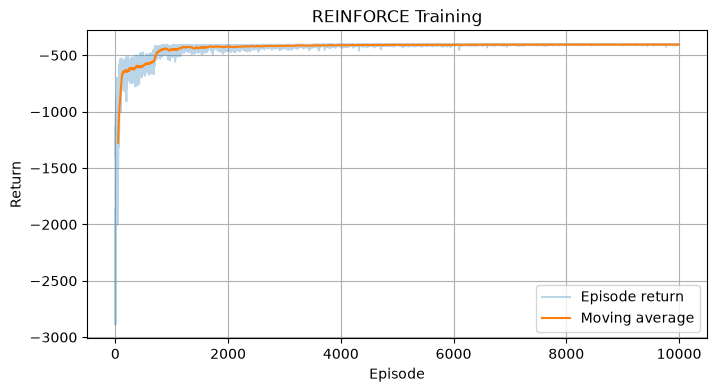

In [31]:
window = 50

moving_average = np.convolve(
    episode_returns,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 4))

plt.plot(
    episode_returns,
    alpha=0.3,
    label="Episode return"
)

plt.plot(
    np.arange(window - 1, N_EPISODES),
    moving_average,
    label="Moving average"
)

plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("REINFORCE Training")
plt.legend()
plt.grid()

plt.show()

## 15. Evaluating the Learned Policy

During training, actions are sampled from:

$$
u_t
\sim
\pi_\theta(\cdot|x_t).
$$

For evaluation, we can use the deterministic action with the largest
probability:

$$
\boxed{
u_t=
\arg\max_u
\pi_\theta(u|x_t).
}
$$

This allows us to inspect what behavior the policy has learned without
additional exploration noise.

In [32]:
def greedy_action(policy, state):

    with torch.no_grad():

        state_tensor = state_to_tensor(
            state
        )

        probabilities = policy(
            state_tensor
        )[0]

    return torch.argmax(
        probabilities
    ).item()

In [33]:
state = np.array([
    0.0,
    0.0
])

states = []
actions = []
rewards = []

for _ in range(EPISODE_LENGTH):

    action_index = greedy_action(
        policy,
        state
    )

    next_state, reward = environment_step(
        state,
        action_index
    )

    states.append(
        state.copy()
    )

    actions.append(
        ACTIONS[action_index]
    )

    rewards.append(
        reward
    )

    state = next_state

states = np.array(states)
actions = np.array(actions)

## 16. Inspecting the Learned Vehicle Behavior

The main task is velocity tracking.

We therefore examine whether the learned policy drives:

$$
v_t
\rightarrow
v_{\text{ref}}.
$$

A successful policy should accelerate while the velocity is below the target
and reduce acceleration once the target velocity is reached.

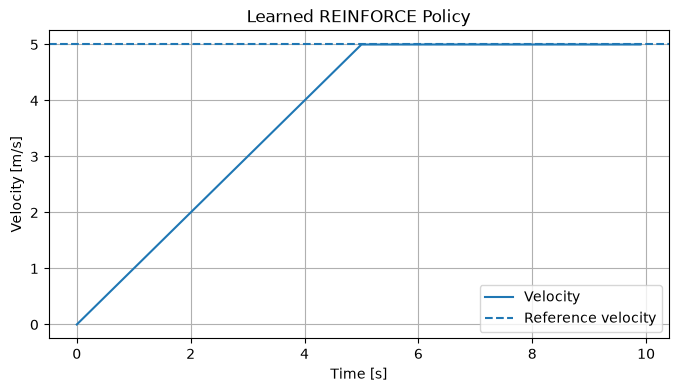

In [34]:
time = (
    np.arange(len(states))
    * DT
)

plt.figure(figsize=(8, 4))

plt.plot(
    time,
    states[:, 1],
    label="Velocity"
)

plt.axhline(
    V_REF,
    linestyle="--",
    label="Reference velocity"
)

plt.xlabel("Time [s]")
plt.ylabel("Velocity [m/s]")
plt.title("Learned REINFORCE Policy")
plt.legend()
plt.grid()

plt.show()

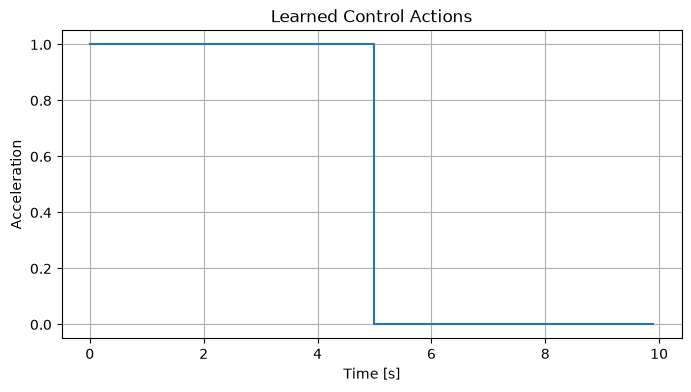

In [35]:
plt.figure(figsize=(8, 4))

plt.step(
    time,
    actions,
    where="post"
)

plt.xlabel("Time [s]")
plt.ylabel("Acceleration")
plt.title("Learned Control Actions")
plt.grid()

plt.show()

## 17. Inspecting the Learned Policy Distribution

A stochastic policy does not merely produce an action.

It represents:

$$
\pi_\theta(u|x).
$$

We can inspect the learned action probabilities at different velocities.

For each velocity, we evaluate:

$$
P(u=-1|x),
$$

$$
P(u=0|x),
$$

and:

$$
P(u=+1|x).
$$

This allows us to visualize how the policy changes its behavior as the vehicle
approaches the desired velocity.

In [36]:
velocity_grid = np.linspace(
    0.0,
    8.0,
    100
)

probabilities = []

for velocity in velocity_grid:

    state = np.array([
        0.0,
        velocity
    ])

    with torch.no_grad():

        probs = policy(
            state_to_tensor(state)
        )[0]

    probabilities.append(
        probs.numpy()
    )

probabilities = np.array(
    probabilities
)

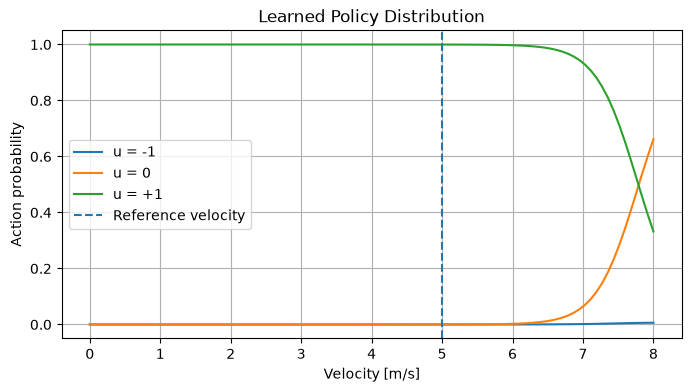

In [37]:
plt.figure(figsize=(8, 4))

plt.plot(
    velocity_grid,
    probabilities[:, 0],
    label="u = -1"
)

plt.plot(
    velocity_grid,
    probabilities[:, 1],
    label="u = 0"
)

plt.plot(
    velocity_grid,
    probabilities[:, 2],
    label="u = +1"
)

plt.axvline(
    V_REF,
    linestyle="--",
    label="Reference velocity"
)

plt.xlabel("Velocity [m/s]")
plt.ylabel("Action probability")
plt.title("Learned Policy Distribution")
plt.legend()
plt.grid()

plt.show()

## 18. The Main Problem With REINFORCE

REINFORCE estimates the policy gradient using sampled trajectories:

$$
\nabla_\theta J
\approx
\sum_t
G_t
\nabla_\theta
\log\pi_\theta(u_t|x_t).
$$

The return:

$$
G_t
$$

depends on many stochastic events that occur after action $u_t$.

Two trajectories generated from the same policy can therefore produce very
different returns.

As a result, the estimated policy gradient can vary significantly from one
episode to another.

This is known as:

$$
\boxed{
\text{high variance}
}
$$

in the policy-gradient estimator.

## 19. Credit Assignment in REINFORCE

Reward-to-go improves credit assignment because an action is not influenced by
rewards that occurred before it.

However:

$$
G_t=
r_{t+1}
+
\gamma r_{t+2}
+
\gamma^2r_{t+3}
+\cdots
$$

still contains the effects of many future actions.

Therefore, the learning signal for:

$$
(x_t,u_t)
$$

can be strongly affected by randomness later in the trajectory.

**Note:** This contributes to the high variance of Monte Carlo policy-gradient methods.

## 20. Introducing a Baseline

The raw return:

$$
G_t
$$

does not tell us whether the selected action performed better or worse than
expected.

Suppose the current state is already favorable.

A high return may occur regardless of which action is selected.

Instead of using the raw return, we can compare it with a baseline:

$$
b(x_t).
$$

The policy-gradient estimator becomes:

$$
\boxed{
\nabla_\theta J
\approx
\sum_t
\left(
G_t-b(x_t)
\right)
\nabla_\theta
\log\pi_\theta(u_t|x_t).
}
$$

The baseline represents the expected quality of the state before considering
the particular sampled action.

## 21. From a Baseline to the Advantage Function

A useful state-dependent baseline is the value function:

$$
V^\pi(x_t).
$$

It represents the expected future return when starting from state $x_t$
and following the current policy.

The policy-gradient signal can therefore use:

$$
G_t - V^\pi(x_t).
$$

This quantity asks:

> Was the outcome after taking this action better or worse than what was
> normally expected from this state?

This leads to the advantage function:

$$
\boxed{
A^\pi(x,u)=
Q^\pi(x,u)-
V^\pi(x)
}
$$

The advantage measures the relative quality of an action compared with the
average behavior of the current policy at the same state.

## 22. Relative Performance Instead of Absolute Return

Using the raw return:

$$
G_t
$$

can be misleading because some states are naturally better than others.

Instead, we compare the observed return with the expected return:

$$
G_t - V^\pi(x_t).
$$

If:

$$
G_t - V^\pi(x_t) > 0,
$$

the action performed better than expected.

If:

$$
G_t - V^\pi(x_t) < 0,
$$

the action performed worse than expected.

Therefore, the policy update becomes:

$$
\boxed{
\nabla_\theta J
\approx
\sum_t
A_t
\nabla_\theta
\log\pi_\theta(u_t|x_t)
}
$$

where $A_t$ is an estimate of the advantage.

## 23. Learning the Baseline

The true state-value function:

$$
V^\pi(x)
$$

is generally unknown.

We therefore approximate it using a neural network:

$$
\boxed{
V_\phi(x)
\approx
V^\pi(x).
}
$$

This network learns to predict the expected future return of the current
policy.

We now have two learnable components:

$$
\pi_\theta(u|x)
$$

and:

$$
V_\phi(x).
$$

The policy chooses actions.

The value function evaluates how good the current situation is expected to be.

## 24. Actor and Critic

The policy network is called the **actor**:

$$
\boxed{
\pi_\theta(u|x)
}
$$

because it determines how the agent acts.

The value network is called the **critic**:

$$
\boxed{
V_\phi(x)
}
$$

because it evaluates the expected quality of the current state.

The actor performs policy improvement.

The critic performs policy evaluation.

Therefore, actor-critic can be viewed as a function-approximation version of
Generalized Policy Iteration:

$$
\boxed{
\text{Policy Evaluation}
\leftrightarrow
\text{Critic}
}
$$

$$
\boxed{
\text{Policy Improvement}
\leftrightarrow
\text{Actor}
}
$$

## 25. A Critic Network

In [39]:
class ValueNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, state):

        return self.network(state)

In [40]:
critic = ValueNetwork()

## 26. Training the Critic With Monte Carlo Returns

The critic approximates:

$$
V^\pi(x_t).
$$

A direct target is the observed reward-to-go:

$$
G_t.
$$

Therefore, the critic can minimize:

$$
\boxed{
L_V(\phi)=
\left(
G_t-V_\phi(x_t)
\right)^2.
}
$$

This is a supervised regression problem:

$$
x_t
\rightarrow
G_t.
$$

The critic learns to predict the expected return generated by the current
policy.

## 27. Actor Update With an Advantage Estimate

Once the critic predicts:

$$
V_\phi(x_t),
$$

we estimate the advantage using:

$$
\hat A_t=
G_t-
V_\phi(x_t).
$$

The actor loss becomes:

$$
\boxed{
L_{\text{actor}}=-
\sum_t
\hat A_t
\log
\pi_\theta(u_t|x_t).
}
$$

If:

$$
\hat A_t>0,
$$

the sampled action becomes more likely.

If:

$$
\hat A_t<0,
$$

the sampled action becomes less likely.

## 28. Temporal-Difference Advantage

Using Monte Carlo returns requires waiting for the future trajectory.

Instead, the critic can use a one-step TD target:

$$
y_t=
r_{t+1}
+
\gamma
V_\phi(x_{t+1}).
$$

The temporal-difference error is:

$$
\boxed{
\delta_t=
r_{t+1}
+
\gamma
V_\phi(x_{t+1})-
V_\phi(x_t).
}
$$

The TD error tells us whether the observed transition was better or worse than
the critic expected.

It can also be used as a one-step estimate of the advantage:

$$
\boxed{
\hat A_t
\approx
\delta_t.
}
$$

## 29. Why the TD Error Represents Advantage?

The advantage is:

$$
A^\pi(x_t,u_t)=
Q^\pi(x_t,u_t)-
V^\pi(x_t).
$$

The action-value function can be written as:

$$
Q^\pi(x_t,u_t)=
\mathbb E
\left[
r_{t+1}
+
\gamma
V^\pi(x_{t+1})
\right].
$$

Therefore:

$$
A^\pi(x_t,u_t)=
\mathbb E
\left[
r_{t+1}+
\gamma
V^\pi(x_{t+1})-
V^\pi(x_t)
\right].
$$

Using one sampled transition gives:

$$
\boxed{
\hat A_t=
r_{t+1}+
\gamma V_\phi(x_{t+1})-
V_\phi(x_t).
}
$$

Thus, the temporal-difference error provides a one-step estimate of how much
better or worse the selected action performed relative to expectation.

## 30. One-Step Actor-Critic

At every transition:

$$
(x_t,u_t,r_{t+1},x_{t+1}),
$$

the critic computes:

$$
\delta_t=
r_{t+1}+
\gamma V_\phi(x_{t+1})-
V_\phi(x_t).
$$

The critic minimizes:

$$
\boxed{
L_{\text{critic}}=
\delta_t^2.
}
$$

The actor uses the TD error as an advantage estimate:

$$
\boxed{
L_{\text{actor}}=-
\delta_t
\log
\pi_\theta(u_t|x_t).
}
$$

Therefore, the critic learns to evaluate the current policy while the actor
changes the policy using the critic's evaluation.

## 31. REINFORCE vs Actor-Critic

REINFORCE uses Monte Carlo returns:

$$
G_t.
$$

The policy update therefore depends on future rewards from the complete
trajectory.

Actor-Critic introduces a learned value function:

$$
V_\phi(x).
$$

A one-step actor-critic method can use:

$$
\delta_t=
r_{t+1}+
\gamma V_\phi(x_{t+1})-
V_\phi(x_t).
$$

This changes the learning process from:

$$
\text{complete trajectory}
\rightarrow
\text{return}
\rightarrow
\text{policy update}
$$

to:

$$
\text{transition}
\rightarrow
\text{TD error}
\rightarrow
\text{actor and critic updates}.
$$

Actor-Critic therefore combines policy-gradient control with temporal-
difference value learning.

## 32. One-Step Actor-Critic for the 1D Car

In one-step actor-critic, learning happens after every transition.

At time $t$:

1. The actor receives the current state:

$$
x_t.
$$

2. It samples an action:

$$
u_t
\sim
\pi_\theta(\cdot|x_t).
$$

3. The environment returns:

$$
r_{t+1},
\qquad
x_{t+1}.
$$

4. The critic computes the temporal-difference error:

$$
\delta_t=
r_{t+1}+
\gamma V_\phi(x_{t+1})-
V_\phi(x_t).
$$

5. The critic uses this error to improve its value estimate.

6. The actor uses the same TD error as an advantage estimate to update the
policy.

Therefore, learning occurs continuously during the trajectory.

In [50]:
actor = PolicyNetwork()
critic = ValueNetwork()

actor_optimizer = optim.Adam(
    actor.parameters(),
    lr=1e-3
)

critic_optimizer = optim.Adam(
    critic.parameters(),
    lr=2e-3
)

## 34. Sampling an Action From the Actor

The actor represents:

$$
\pi_\theta(u|x).
$$

During training, we sample an action from this distribution.

The actor update later requires:

$$
\log\pi_\theta(u_t|x_t).
$$

Therefore, each action selection returns both the sampled action and its
log-probability.

In [51]:
def sample_actor_action(
    actor,
    state
):

    state_tensor = state_to_tensor(
        state
    )

    probabilities = actor(
        state_tensor
    )[0]

    distribution = torch.distributions.Categorical(
        probabilities
    )

    action_index = distribution.sample()

    log_prob = distribution.log_prob(
        action_index
    )

    return (
        action_index.item(),
        log_prob
    )

## 35. Critic TD Target

For a non-terminal transition, the critic target is:

$$
y_t=
r_{t+1}
+
\gamma
V_\phi(x_{t+1}).
$$

The critic prediction is:

$$
V_\phi(x_t).
$$

Therefore, the TD error is:

$$
\delta_t=
y_t-
V_\phi(x_t).
$$

At the final step of the finite episode, we treat the horizon as terminal and
use:

$$
y_t=
r_{t+1}.
$$

## 36. One Actor-Critic Update

In [52]:
def actor_critic_update(
    actor,
    critic,
    actor_optimizer,
    critic_optimizer,
    state,
    action_log_prob,
    reward,
    next_state,
    done,
    gamma=0.99
):

    state_tensor = state_to_tensor(
        state
    )

    next_state_tensor = state_to_tensor(
        next_state
    )

    value = critic(
        state_tensor
    ).squeeze()

    with torch.no_grad():

        if done:
            td_target = torch.tensor(
                reward,
                dtype=torch.float32
            )

        else:
            next_value = critic(
                next_state_tensor
            ).squeeze()

            td_target = (
                reward
                + gamma * next_value
            )

    td_error = (
        td_target - value
    )

    critic_loss = td_error.pow(2)

    critic_optimizer.zero_grad()

    critic_loss.backward()

    critic_optimizer.step()

    actor_loss = (
        -action_log_prob
        * td_error.detach()
    )

    actor_optimizer.zero_grad()

    actor_loss.backward()

    actor_optimizer.step()

    return (
        actor_loss.item(),
        critic_loss.item(),
        td_error.item()
    )

## 37. Why the Advantage Signal Is Detached?

The actor loss is:

$$
L_{\text{actor}}=-
\delta_t
\log
\pi_\theta(u_t|x_t).
$$

The TD error is computed using the critic:

$$
\delta_t=
r_{t+1}+
\gamma V_\phi(x_{t+1})-
V_\phi(x_t).
$$

However, during the actor update, we want to optimize only the actor
parameters:

$$
\theta.
$$

The critic parameters:

$$
\phi
$$

should be updated only through the critic loss.

Therefore, we treat:

$$
\delta_t
$$

as a fixed learning signal during the actor update.

In PyTorch, this is done using:

```python
td_error.detach()


So conceptually:

$$
\boxed{
\text{critic produces the evaluation}
}
$$

and

$$
\boxed{
\text{actor uses that evaluation}
}
$$

without the actor update modifying the critic.

---
## 38. Actor-Critic Training Loop

Unlike REINFORCE, one-step actor-critic does not wait until the end of the
trajectory to update the policy.

At every transition:

$$
(x_t,u_t,r_{t+1},x_{t+1}),
$$

we immediately compute a TD error and update both networks.

The loop is:

$$
\boxed{
\text{state}
\rightarrow
\text{actor}
\rightarrow
\text{action}
\rightarrow
\text{environment}
\rightarrow
\text{TD error}
\rightarrow
\text{actor + critic updates}
}
$$

In [53]:
N_EPISODES = 2000
GAMMA = 0.99

episode_returns_ac = []
actor_loss_history = []
critic_loss_history = []
td_error_history = []

In [54]:
for episode in range(N_EPISODES):

    state = np.array([
        0.0,
        0.0
    ])

    episode_return = 0.0

    for t in range(EPISODE_LENGTH):

        action_index, log_prob = sample_actor_action(
            actor,
            state
        )

        next_state, reward = environment_step(
            state,
            action_index
        )

        done = (
            t == EPISODE_LENGTH - 1
        )

        (
            actor_loss,
            critic_loss,
            td_error
        ) = actor_critic_update(
            actor,
            critic,
            actor_optimizer,
            critic_optimizer,
            state,
            log_prob,
            reward,
            next_state,
            done,
            gamma=GAMMA
        )

        episode_return += reward

        actor_loss_history.append(
            actor_loss
        )

        critic_loss_history.append(
            critic_loss
        )

        td_error_history.append(
            td_error
        )

        state = next_state

    episode_returns_ac.append(
        episode_return
    )

    if episode % 100 == 0:

        print(
            f"Episode {episode:4d} | "
            f"Return: {episode_return:8.2f}"
        )

Episode    0 | Return: -1836.28
Episode  100 | Return:  -827.74
Episode  200 | Return:  -833.50
Episode  300 | Return: -9462.77
Episode  400 | Return: -10933.50
Episode  500 | Return:  -534.30
Episode  600 | Return:  -833.50
Episode  700 | Return:  -833.50
Episode  800 | Return:  -833.50
Episode  900 | Return:  -833.50
Episode 1000 | Return: -2500.00
Episode 1100 | Return: -2500.00
Episode 1200 | Return: -2500.00
Episode 1300 | Return: -2500.00
Episode 1400 | Return: -2500.00
Episode 1500 | Return: -2500.00
Episode 1600 | Return: -2500.00
Episode 1700 | Return: -2500.00
Episode 1800 | Return: -2500.00
Episode 1900 | Return: -2500.00


## 39. Visualizing Actor-Critic Training

The episode return measures the task performance of the current actor.

Because the policy remains stochastic during training, individual episode
returns may still fluctuate.

A moving average is therefore useful for examining the overall learning trend.

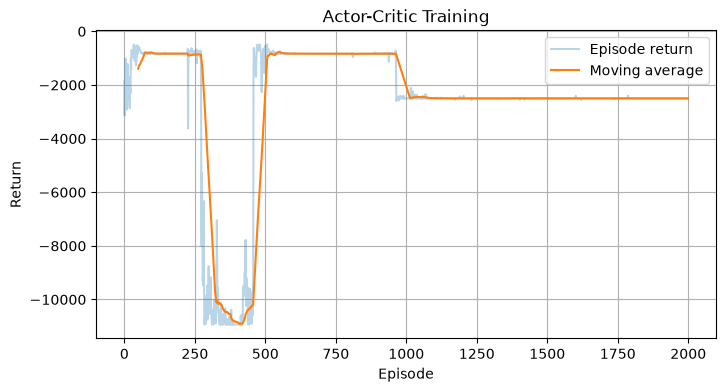

In [55]:
window = 50

moving_average_ac = np.convolve(
    episode_returns_ac,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 4))

plt.plot(
    episode_returns_ac,
    alpha=0.3,
    label="Episode return"
)

plt.plot(
    np.arange(
        window - 1,
        len(episode_returns_ac)
    ),
    moving_average_ac,
    label="Moving average"
)

plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Actor-Critic Training")
plt.legend()
plt.grid()

plt.show()

## 40. Evaluating the Learned Actor

During training, the actor samples actions:

$$
u_t
\sim
\pi_\theta(\cdot|x_t).
$$

For evaluation, we choose the most probable action:

$$
u_t=
\arg\max_u
\pi_\theta(u|x_t).
$$

We then inspect whether the learned policy tracks:

$$
v_{\text{ref}}.
$$

In [56]:
def greedy_actor_action(
    actor,
    state
):

    with torch.no_grad():

        probabilities = actor(
            state_to_tensor(state)
        )[0]

    return torch.argmax(
        probabilities
    ).item()

In [57]:
state = np.array([
    0.0,
    0.0
])

ac_states = []
ac_actions = []

for _ in range(EPISODE_LENGTH):

    action_index = greedy_actor_action(
        actor,
        state
    )

    next_state, reward = environment_step(
        state,
        action_index
    )

    ac_states.append(
        state.copy()
    )

    ac_actions.append(
        ACTIONS[action_index]
    )

    state = next_state

ac_states = np.array(ac_states)
ac_actions = np.array(ac_actions)

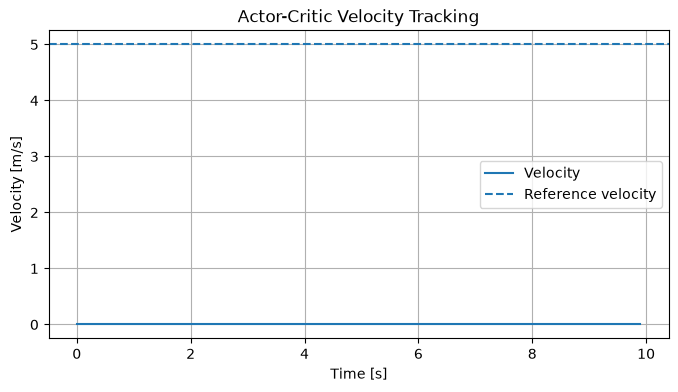

In [58]:
time = (
    np.arange(len(ac_states))
    * DT
)

plt.figure(figsize=(8, 4))

plt.plot(
    time,
    ac_states[:, 1],
    label="Velocity"
)

plt.axhline(
    V_REF,
    linestyle="--",
    label="Reference velocity"
)

plt.xlabel("Time [s]")
plt.ylabel("Velocity [m/s]")
plt.title("Actor-Critic Velocity Tracking")
plt.legend()
plt.grid()

plt.show()

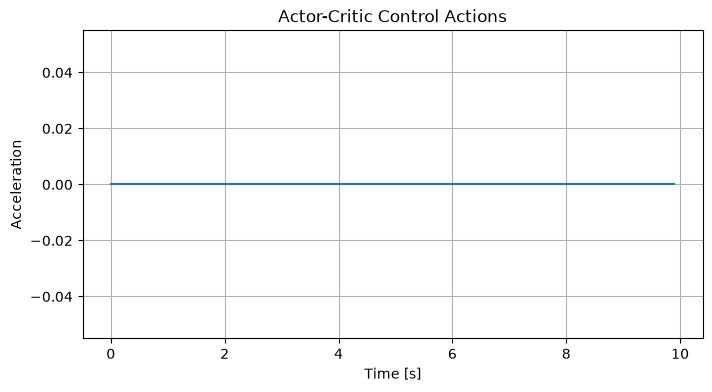

In [59]:
plt.figure(figsize=(8, 4))

plt.step(
    time,
    ac_actions,
    where="post"
)

plt.xlabel("Time [s]")
plt.ylabel("Acceleration")
plt.title("Actor-Critic Control Actions")
plt.grid()

plt.show()

## 42. REINFORCE vs Actor-Critic

REINFORCE uses the sampled Monte Carlo return:

$$
G_t
$$

to update the policy.

Its learning signal is:

$$
G_t
\nabla_\theta
\log
\pi_\theta(u_t|x_t).
$$

One-step actor-critic instead uses the TD error:

$$
\delta_t=
r_{t+1}+
\gamma V_\phi(x_{t+1})-
V_\phi(x_t).
$$

Its actor learning signal is:

$$
\delta_t
\nabla_\theta
\log
\pi_\theta(u_t|x_t).
$$

Therefore:

| Property | REINFORCE | One-Step Actor-Critic |
|---|---|---|
| Policy | Stochastic actor | Stochastic actor |
| Value function | Not required | Learned critic |
| Learning target | Monte Carlo return | TD target |
| Bootstrapping | No | Yes |
| Update frequency | Usually after episode | Can update every transition |
| Variance | Higher | Usually lower |
| Bias | Lower | Can be higher due to bootstrapping |

Actor-critic trades some bias for reduced variance and more frequent learning.

## 43. Actor-Critic as Generalized Policy Iteration

Earlier, reinforcement learning was divided into two interacting problems:

### Prediction

Evaluate the current policy:

$$
\pi
\rightarrow
V^\pi.
$$

### Control

Improve the policy using the current evaluation.

Actor-critic implements the same structure using function approximation.

The critic performs approximate policy evaluation:

$$
V_\phi(x)
\approx
V^{\pi_\theta}(x).
$$

The actor performs policy improvement:

$$
\pi_\theta
\rightarrow
\pi_{\theta'}.
$$

Therefore:

$$
\boxed{
\text{Critic}
\leftrightarrow
\text{Prediction / Policy Evaluation}
}
$$

and:

$$
\boxed{
\text{Actor}
\leftrightarrow
\text{Control / Policy Improvement}.
}
$$

Actor and critic continually adapt to one another, forming a function-
approximation version of Generalized Policy Iteration.

## 45. From Discrete to Continuous Actions

Until now, the vehicle acceleration has been discretized:

$$
u_t\in\{-1,0,+1\}.
$$

This allowed the actor to represent a categorical distribution:

$$
\pi_\theta(u|x)=
[
P(u=-1|x),
P(u=0|x),
P(u=+1|x)
].
$$

However, control inputs in robotics are often continuous.

For our vehicle, we would instead like:

$$
u_t\in\mathbb R.
$$

For example:

$$
u_t=0.37\text{ m/s}^2.
$$

A policy-gradient method can represent this directly by defining a continuous
probability distribution over actions.

## 46. Gaussian Policy

For a continuous action, the actor can represent a Gaussian policy:

$$
\boxed{
u_t
\sim
\mathcal N
\left(
\mu_\theta(x_t),
\sigma_\theta(x_t)^2
\right).
}
$$

The actor determines two quantities:

$$
\mu_\theta(x_t)
$$

and:

$$
\sigma_\theta(x_t).
$$

The mean determines the central action preferred by the policy.

The standard deviation determines how stochastic the policy is.

During training:

$$
u_t
\sim
\mathcal N(\mu_t,\sigma_t^2).
$$

For deterministic evaluation, we can use:

$$
u_t=\mu_\theta(x_t).
$$

## 47. Parameterizing the Standard Deviation

A Gaussian standard deviation must satisfy:

$$
\sigma>0.
$$

Instead of directly learning $\sigma$, we can learn:

$$
\log\sigma.
$$

The standard deviation is then recovered using:

$$
\boxed{
\sigma=
\exp(\log\sigma).
}
$$

This guarantees that the policy always produces a valid positive standard
deviation.

In [61]:
class ContinuousActor(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh()
        )

        self.mean_head = nn.Linear(
            32,
            1
        )

        self.log_std = nn.Parameter(
            torch.tensor([-0.5])
        )

    def forward(self, state):

        features = self.network(
            state
        )

        mean = self.mean_head(
            features
        )

        std = torch.exp(
            self.log_std
        )

        return mean, std

## 49. Continuous Vehicle Control

The vehicle dynamics remain:

$$
p_{t+1}=
p_t+\Delta t\,v_t,
$$

$$
v_{t+1}=
v_t+\Delta t\,u_t.
$$

However, the control is now continuous:

$$
u_t\in[u_{\min},u_{\max}].
$$

We use:

$$
u_{\min}=-1,
\qquad
u_{\max}=1.
$$

The task remains velocity tracking:

$$
v_t\rightarrow v_{\text{ref}}.
$$

In [62]:
U_MIN = -1.0
U_MAX = 1.0


def continuous_environment_step(
    state,
    acceleration
):

    position, velocity = state

    acceleration = np.clip(
        acceleration,
        U_MIN,
        U_MAX
    )

    next_position = (
        position
        + DT * velocity
    )

    next_velocity = (
        velocity
        + DT * acceleration
    )

    next_state = np.array([
        next_position,
        next_velocity
    ])

    velocity_error = (
        next_velocity - V_REF
    )

    reward = -velocity_error**2

    return next_state, reward

## 50. Sampling From a Continuous Policy

For a state $x_t$, the actor produces:

$$
\mu_t,\sigma_t.
$$

These define:

$$
\pi_\theta(u|x_t)=
\mathcal N(\mu_t,\sigma_t^2).
$$

We sample:

$$
u_t
\sim
\pi_\theta(\cdot|x_t).
$$

Just as with the categorical policy, we also calculate:

$$
\log\pi_\theta(u_t|x_t).
$$

Therefore, the policy-gradient expression remains:

$$
\boxed{
\nabla_\theta J
\approx
\sum_t
\hat A_t
\nabla_\theta
\log\pi_\theta(u_t|x_t).
}
$$

The policy-gradient framework is unchanged; only the probability distribution
over actions has changed.

In [63]:
def sample_continuous_action(
    actor,
    state
):

    state_tensor = state_to_tensor(
        state
    )

    mean, std = actor(
        state_tensor
    )

    distribution = torch.distributions.Normal(
        mean,
        std
    )

    action = distribution.sample()

    log_prob = distribution.log_prob(
        action
    ).sum()

    acceleration = action.item()

    acceleration = np.clip(
        acceleration,
        U_MIN,
        U_MAX
    )

    return (
        acceleration,
        log_prob
    )

## 52. Continuous Actor-Critic

The critic does not need to change when moving from discrete to continuous
actions.

It still approximates:

$$
V_\phi(x)
\approx
V^{\pi_\theta}(x).
$$

The TD error remains:

$$
\delta_t=
r_{t+1}+
\gamma V_\phi(x_{t+1})-
V_\phi(x_t).
$$

The actor loss also retains the same form:

$$
L_{\text{actor}}=-
\delta_t
\log
\pi_\theta(u_t|x_t).
$$

The only major difference is the policy distribution:

$$
\text{Categorical}
\rightarrow
\text{Gaussian}.
$$

## 53. Why Policy Gradients Fit Continuous Control?

Value-based control requires action selection through:

$$
u^*=
\arg\max_u
Q_\phi(x,u).
$$

For a small discrete action space, this is easy because all actions can be
evaluated.

For a continuous action space:

$$
u\in\mathbb R^m,
$$

the maximization itself becomes a continuous optimization problem.

Policy-based methods avoid this requirement.

The actor directly represents:

$$
\pi_\theta(u|x),
$$

and can generate continuous controls without solving a separate optimization
problem at every time step.

This makes policy-based and actor-critic methods particularly natural for
continuous-control problems in robotics.

## 54. The Remaining Problem: Large Policy Updates

Actor-critic improves policy-gradient learning by introducing a critic and an
advantage estimate.

However, a vanilla policy-gradient update can still change the policy too
aggressively.

A large parameter update may cause:

$$
\pi_{\theta_{\text{new}}}(u|x)
$$

to become very different from:

$$
\pi_{\theta_{\text{old}}}(u|x).
$$

Since the policy determines the data distribution, a large change in the
policy also changes the states and actions that the agent will experience.

This can make policy optimization unstable.

The next question is therefore:

> How can we improve the policy while preventing each update from changing it
> too much?

This motivates trust-region methods and, eventually:

$$
\boxed{
\text{Proximal Policy Optimization (PPO)}.
}
$$

## 55. Policy Gradients and Actor-Critic — Summary

This notebook moved from value-based reinforcement learning to direct policy
optimization.

### Policy Gradient

Instead of learning:

$$
Q_\phi(x,u)
$$

and deriving:

$$
u=\arg\max_u Q_\phi(x,u),
$$

we directly parameterized:

$$
\pi_\theta(u|x).
$$

The policy-gradient theorem gives the learning direction:

$$
\nabla_\theta J
\approx
\sum_t
G_t
\nabla_\theta
\log\pi_\theta(u_t|x_t).
$$

### REINFORCE

REINFORCE estimates the policy gradient using Monte Carlo returns:

$$
G_t.
$$

This is simple but can have high variance.

### Baseline and Advantage

A state-value baseline allows us to measure whether an action performed better
or worse than expected:

$$
A^\pi(x,u)=
Q^\pi(x,u)-
V^\pi(x).
$$

### Actor-Critic

The actor represents the policy:

$$
\pi_\theta(u|x),
$$

while the critic approximates:

$$
V_\phi(x).
$$

The TD error:

$$
\delta_t=
r_{t+1}+
\gamma V_\phi(x_{t+1})-
V_\phi(x_t)
$$

provides a one-step advantage estimate.

This gives:

$$
\boxed{
\text{Actor-Critic}=
\text{Policy Gradient}
+
\text{TD Value Learning}.
}
$$

The critic performs approximate policy evaluation, while the actor performs
policy improvement.

### Continuous Control

For continuous actions, the actor can represent a Gaussian policy:

$$
u_t
\sim
\mathcal N
\left(
\mu_\theta(x_t),
\sigma_\theta(x_t)^2
\right).
$$

The underlying policy-gradient principle remains unchanged.

### Next Step

Vanilla policy-gradient and actor-critic updates can change the policy too
aggressively.

This motivates:

$$
\boxed{
\text{Policy Gradient}
\rightarrow
\text{Trust Region}
\rightarrow
\text{PPO}.
}
$$